# Importation des dépendances et chargement du dataset


In [30]:
# Importation des dépendances
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

%cd "/content/drive/MyDrive/Colab Notebooks/notebooks"
df_1 = pd.read_csv('student_habits_performance.csv')

ModuleNotFoundError: No module named 'google.colab'

In [75]:
# Chargement du dataset
df = pd.read_csv("C:/Users/HP/Documents/GitHub/TPs/OPTIMISATION/student_habits_performance.csv")



 # Exploration et visualisation du dataset

In [76]:
# Dimension du dataset et ses 5 premières lignes
shape = df.shape
print(df.shape)
print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes :\n ")
df.head()


(1000, 16)
Le dataset contient 1000 lignes et 16 colonnes :
 


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [77]:
# Colonnes et leur types
df.dtypes

student_id                        object
age                                int64
gender                            object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating               int64
extracurricular_participation     object
exam_score                       float64
dtype: object

# TRAITEMENT DU DATASET

In [78]:
# Suppression de la colonne student_id
df = df.drop('student_id', axis=1)

In [79]:
# Vérification de la présence des valeurs manquantes NaN
df.isna().sum()



age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [80]:
# Imputation par le mode

df["parental_education_level"] = df['parental_education_level'].fillna(df['parental_education_level'].mode()[0])

df.isna().sum()

age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [81]:
# Séparation des données numériques et des données non-numériques
num_cols = df.select_dtypes(include=np.number)
cat_cols = df.select_dtypes(exclude=np.number)


Les colonnes study_hours_per_day social_media_hours netflix_hours attendance_percentage sleep_hours et exam_score présentent des outliers


In [82]:
dummies = pd.get_dummies(cat_cols)
df_final = pd.concat([num_cols, dummies], axis=1)
df_final.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,gender_Female,...,diet_quality_Good,diet_quality_Poor,parental_education_level_Bachelor,parental_education_level_High School,parental_education_level_Master,internet_quality_Average,internet_quality_Good,internet_quality_Poor,extracurricular_participation_No,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2,True,...,False,False,False,False,True,True,False,False,False,True
1,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0,True,...,True,False,False,True,False,True,False,False,True,False
2,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3,False,...,False,True,False,True,False,False,False,True,True,False
3,23,1.0,3.9,1.0,71.0,9.2,4,1,26.8,True,...,False,True,False,False,True,False,True,False,False,True
4,19,5.0,4.4,0.5,90.9,4.9,3,1,66.4,True,...,False,False,False,False,True,False,True,False,True,False


In [83]:
# Features et target
X = df_final.drop('exam_score', axis=1)
y = df_final['exam_score']

# Entraînement

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [85]:
# Mise à l'échelle des valeurs numériques
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Deep Learning


In [86]:

#Paramètres
taux_initial             = 1e-3   # Taux d'apprentissage de départ
decroissance_toutes      = 50     # Diviser par 10 toutes les 50 epochs
patience_stagnation      = 10     # Nb d'epochs sans amélioration → augmenter le taux
facteur_stagnation       = 5      # Multiplier le taux par ce facteur si stagnation
seuil_chute_brutale      = 0.3    # Si la loss chute de plus de 30% en 1 epoch
seuil_gain_validation    = 0.01   # Mais val_loss ne s'améliore pas de 1% → diminuer
facteur_reduction        = 10     # Diviser le taux par 10 dans ce cas

total_epochs             = 200

In [87]:

modele = Sequential([
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16,activation='relu'),
    Dense(1,  activation="linear")
])

optimiseur = tf.keras.optimizers.Adam(learning_rate=taux_initial)
modele.compile(optimizer=optimiseur, loss="mse", metrics=["mae"])


In [88]:
# Historique manuel
historique_perte          = []
historique_perte_val      = []
historique_taux           = []

meilleure_perte_val       = np.inf
epochs_sans_amelioration  = 0

In [89]:



# Boucle d'entraînement epoch par epoch
for epoch in range(1, total_epochs + 1):

    h = modele.fit(X_train, y_train,
                   validation_data=(X_test, y_test),
                   epochs=1, verbose=0)

    perte_entrainement = h.history['loss'][0]
    perte_validation   = h.history['val_loss'][0]

    historique_perte.append(perte_entrainement)
    historique_perte_val.append(perte_validation)

    taux_actuel = float(optimiseur.learning_rate)
    historique_taux.append(taux_actuel)

    # RÈGLE 1 : Décroissance toutes les 50 epochs
    if epoch % decroissance_toutes == 0:
        nouveau_taux = taux_actuel / 10
        optimiseur.learning_rate.assign(nouveau_taux)
        print(f"[Epoch {epoch}]  Décroissance automatique → Taux = {nouveau_taux:.2e}")
        taux_actuel = nouveau_taux

    # RÈGLE 2 : Stagnation → augmenter le taux
    elif perte_validation < meilleure_perte_val * 0.999:
        meilleure_perte_val      = perte_validation
        epochs_sans_amelioration = 0
    else:
        epochs_sans_amelioration += 1
        if epochs_sans_amelioration >= patience_stagnation:
            nouveau_taux = taux_actuel * facteur_stagnation
            optimiseur.learning_rate.assign(nouveau_taux)
            print(f"[Epoch {epoch}]  Stagnation ({epochs_sans_amelioration} epochs) → Taux = {nouveau_taux:.2e}")
            epochs_sans_amelioration = 0
            taux_actuel = nouveau_taux

    #RÈGLE 3 : Chute brutale sans gain validation -> diminuer le taux
    if len(historique_perte) >= 2:
        perte_precedente    = historique_perte[-2]
        ratio_chute         = (perte_precedente - perte_entrainement) / (perte_precedente + 1e-8)

        val_precedente      = historique_perte_val[-2]
        gain_validation     = (val_precedente - perte_validation) / (val_precedente + 1e-8)

        if ratio_chute > seuil_chute_brutale and gain_validation < seuil_gain_validation:
            nouveau_taux = taux_actuel / facteur_reduction
            optimiseur.learning_rate.assign(nouveau_taux)
            print(f"[Epoch {epoch}]  Chute brutale (entr.↓{ratio_chute:.0%}, val≈) → Taux = {nouveau_taux:.2e}")

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | perte={perte_entrainement:.4f} | perte_val={perte_validation:.4f} | taux={taux_actuel:.2e}")



Epoch  10 | perte=44.0704 | perte_val=59.5392 | taux=1.00e-03
Epoch  20 | perte=31.4758 | perte_val=49.6936 | taux=1.00e-03
Epoch  30 | perte=25.4161 | perte_val=45.6833 | taux=1.00e-03
Epoch  40 | perte=20.2000 | perte_val=42.5396 | taux=1.00e-03
[Epoch 50]  Décroissance automatique → Taux = 1.00e-04
Epoch  50 | perte=15.7351 | perte_val=39.8810 | taux=1.00e-04
Epoch  60 | perte=12.7687 | perte_val=37.1432 | taux=1.00e-04
Epoch  70 | perte=12.3342 | perte_val=36.6221 | taux=1.00e-04
Epoch  80 | perte=11.8032 | perte_val=36.3754 | taux=1.00e-04
Epoch  90 | perte=11.3521 | perte_val=35.9607 | taux=1.00e-04
[Epoch 100]  Décroissance automatique → Taux = 1.00e-05
Epoch 100 | perte=10.9040 | perte_val=35.9487 | taux=1.00e-05
[Epoch 101]  Stagnation (10 epochs) → Taux = 5.00e-05
Epoch 110 | perte=10.5482 | perte_val=35.8937 | taux=5.00e-05
Epoch 120 | perte=10.3567 | perte_val=35.8513 | taux=5.00e-05
[Epoch 124]  Stagnation (10 epochs) → Taux = 2.50e-04
Epoch 130 | perte=9.9727 | perte_val=

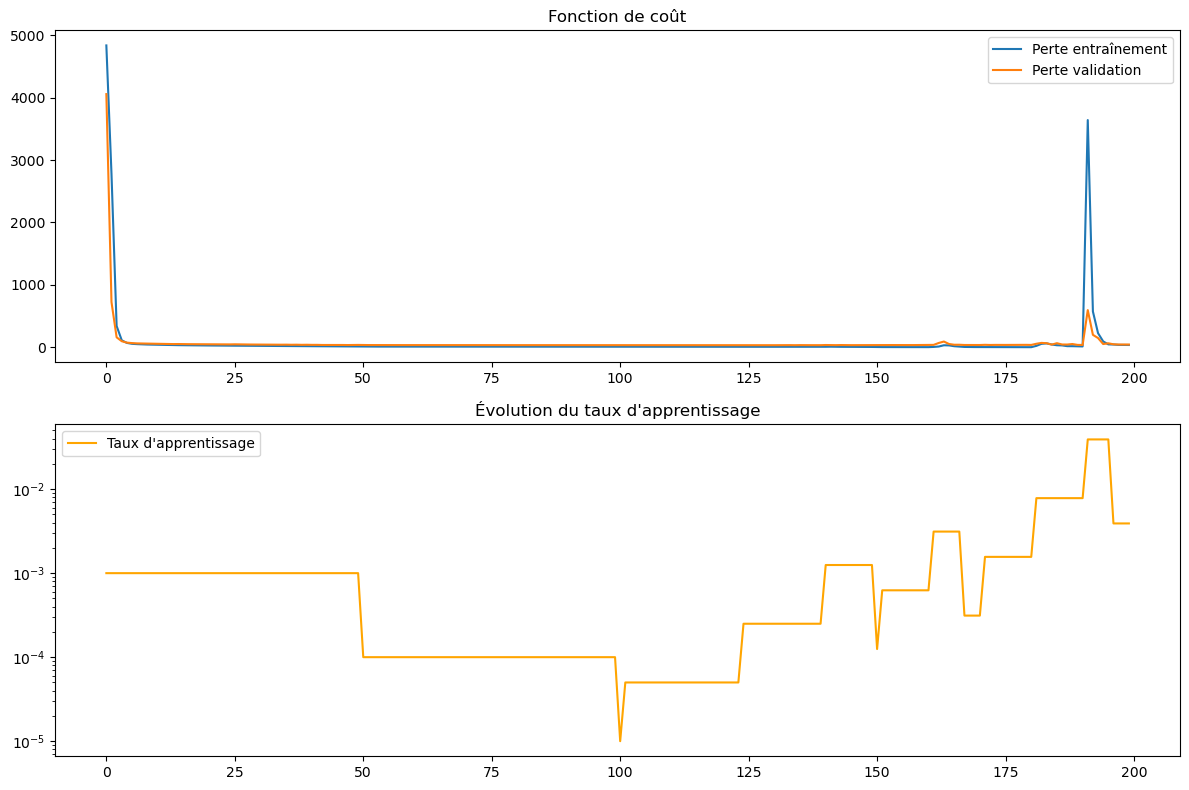

In [90]:
# Visualisation


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(historique_perte,     label='Perte entraînement')
ax1.plot(historique_perte_val, label='Perte validation')
ax1.set_title('Fonction de coût')
ax1.legend()

ax2.plot(historique_taux, color='orange', label='Taux d\'apprentissage')
ax2.set_title('Évolution du taux d\'apprentissage')
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
plt.show()

1. Le problème de l'Oscillation en fin de convergence

Problème : Avec un taux d'apprentissage fixe, le modèle finit par "rebondir" autour du minimum de la fonction de coût sans jamais l'atteindre, car ses pas sont trop grands pour la courbure locale.

Solution (decroissance_toutes = 50) : La réduction forcée du learning rate diminue la variance des mises à jour des poids, permettant de stabiliser la descente dans les zones les plus étroites de la surface de perte.


2. Le blocage dans les Minima Locaux ou Plateaux

Problème : Le gradient peut devenir proche de zéro (plateau) ou le modèle peut se piéger dans un minimum local sous-optimal. L'optimiseur n'a alors plus assez d'énergie pour s'en extraire.

Solution (patience_stagnation = 10 + facteur_stagnation = 5) : En augmentant brutalement le taux d'apprentissage, on augmente la magnitude de la mise à jour des poids. Cela crée une "perturbation" volontaire pour projeter les paramètres du modèle hors de la zone de stagnation vers une zone où le gradient est plus marqué.

3. La Déconnexion Entraînement/Validation (Overfitting brutal)

Problème : Une chute rapide de la perte d'entraînement (ratio_chute > 0.3) sans baisse équivalente en validation signifie que l'optimiseur a trouvé un chemin numérique qui minimise l'erreur sur le train par pur calcul mathématique (mémorisation du bruit), mais ne généralise pas.

Solution (seuil_gain_validation = 0.01 + facteur_reduction = 10) : Si ce déséquilibre est détecté, le code réduit immédiatement le taux d'apprentissage. Cela contraint l'optimiseur à effectuer des mises à jour beaucoup plus fines, ce qui limite sa capacité à s'ajuster trop brutalement aux spécificités (le bruit) du jeu d'entraînement.

In [91]:
# 1. Reconstruction du modèle identique
modele_fixe = Sequential([
    Dense(128,activation='relu'),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1,  activation="linear")
])


optimiseur_fixe = tf.keras.optimizers.Adam(learning_rate=1e-3)
modele_fixe.compile(optimizer=optimiseur_fixe, loss="mse", metrics=["mae"])

# 3. Entraînement classique en un seul bloc
print("Lancement de l'entraînement standard...")
historique_fixe = modele_fixe.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200, # Même nombre d'epochs
    verbose=0
)
print("Entraînement terminé.")

Lancement de l'entraînement standard...
Entraînement terminé.


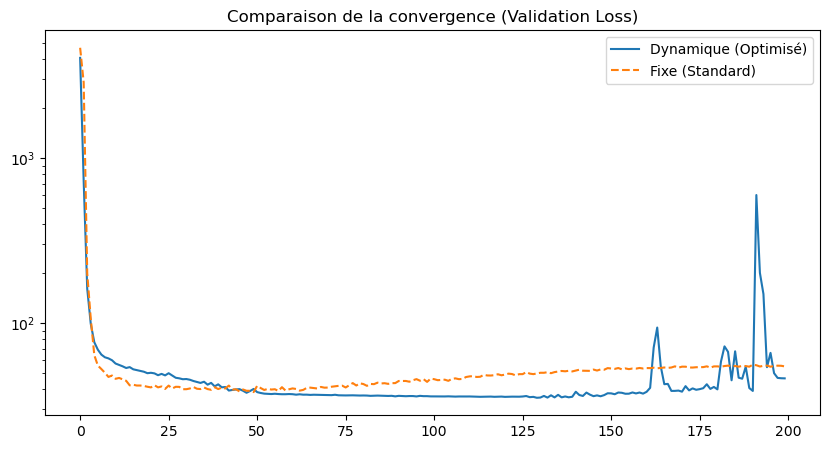

In [92]:
plt.figure(figsize=(10, 5))
plt.plot(historique_perte_val, label='Dynamique (Optimisé)')
plt.plot(historique_fixe.history['val_loss'], label='Fixe (Standard)', linestyle='--')
plt.title('Comparaison de la convergence (Validation Loss)')
plt.yscale('log')
plt.legend()
plt.show()

In [93]:
from sklearn.metrics import mean_squared_error, r2_score

# Prédictions
pred_dynamique = modele.predict(X_test)
pred_fixe      = modele_fixe.predict(X_test)

# Calcul RMSE
rmse_dynamique = np.sqrt(mean_squared_error(y_test, pred_dynamique))
rmse_fixe      = np.sqrt(mean_squared_error(y_test, pred_fixe))

# Calcul R²
r2_dynamique = r2_score(y_test, pred_dynamique)
r2_fixe      = r2_score(y_test, pred_fixe)

print(f"Modèle Fixe      | RMSE: {rmse_fixe:.4f} | R²: {r2_fixe:.4f}")
print(f"Modèle Dynamique | RMSE: {rmse_dynamique:.4f} | R²: {r2_dynamique:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Modèle Fixe      | RMSE: 7.3928 | R²: 0.7869
Modèle Dynamique | RMSE: 6.7992 | R²: 0.8197


## Regression linéaire

In [94]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [95]:
# Prédiction sur les données de test
y_pred = model.predict(X_test)

In [96]:
# Calcul des métriques d'évaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE : {mse}\nR2 : {r2}")

MSE : 26.532535044099458
R2 : 0.8965307156715966


# Conclusion

L'analyse a comparé les performances d'un modèle de Deep Learning et d'un modèle de Régression Linéaire pour prédire les scores aux examens. Les métriques d'évaluation  ont montré que le modèle de **Régression Linéaire** a surpassé le modèle de Deep Learning en terme de R2 mais le MSE du Deep Learning est le plus petit.

*   **Régression Linéaire :**
    *   MSE : 26.53
    *   R2 : 0.8965

*   **Deep Learning (meilleures performances autour de 50 époques) :**
    *   MSE : 6.7992
    *   R2 : 0.8197

Il est important de noter que l'augmentation du nombre d'époques pour le modèle de Deep Learning (notamment au-delà de 50 époques) a entraîné une détérioration de ses performances (augmentation de la MSE et diminution du R2), suggérant un phénomène de surapprentissage (overfitting). Dans ce cas précis, un modèle de régression linéaire plus simple s'est avéré plus efficace et robuste.